# 🌊 Phase 2 — 3-Class Flood Segmentation Baseline

**Task**: Segment satellite images into 3 classes:
- `0` — No Flood (land)
- `1` — Flood (target class)
- `2` — Water Body (permanent)

**Architecture**: UNet + ResNet50 (ImageNet pretrained) + Channel Adapter (6→3ch)
**Loss**: Focal Loss with class weighting
**Data**: 6 bands — HH, HV, Green, Red, NIR, SWIR (512×512 patches)

## 0. Setup & Reproducibility

In [1]:
# !pip install -U imagecodecs

In [2]:
# !pip install -q rasterio

In [3]:
import os
import random
import warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import tifffile
import pandas as pd
from collections import defaultdict
import time

warnings.filterwarnings("ignore")
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# ── Reproducibility ──────────────────────────────────────────
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)
print(f"Seed: {SEED}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Seed: 42
PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4
Device: cuda


## 1. Configuration

In [4]:
BestBands = [0, 1, 2, 3, 4]
BestIndices = []
BestLoss = "focal_dice"

In [5]:
# ── All hyperparameters in one place ─────────────────────────
CONFIG = {
    # Paths (Kaggle)
    "image_dir": "/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/image",
    "label_dir": "/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/label",
    "predict_dir": "/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/prediction/image",
    "split_dir": "/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/split",

    # Model
    "backbone": "resnet101",
    "decoder": "UnetPlusPlus",
    "num_classes": 3,
    "adapter_channels": 32,

    # Data
    "input_bands": [0, 1, 2 , 3 ,4 ],  # HH, HV, Green, Red, NIR, SWIR
    "spectral_indices": [],  # Empty for baseline; options: ["ndwi", "mndwi", "ndvi", "sar_ratio"]
    # Normalization (exact stats from all 79 Phase 2 images)
    "means": [801.7888, 357.1027, 1836.6330, 1688.3822, 1812.1369, 1275.3099],
    "stds":  [435.3025, 164.0302, 628.8165, 615.6047, 588.7599, 543.9400],

    # Training
    "epochs": 100,
    "batch_size": 4,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "scheduler": "cosine",
    "eta_min": 1e-6,
    "grad_accum_steps": 4,  # Effective batch 
    "mixed_precision": True,
    "freeze_backbone_epochs": 10,

    # Loss
    "focal_gamma": 2.0,
    "focal_alpha": [0.15, 0.60, 0.25],  # [no_flood, flood, water_body]

    # Early stopping
    "patience": 15,
    "save_top_k": 3,
}

# Fix paths for local testing (auto-detect)
if not os.path.exists(CONFIG["image_dir"]):
    print("[INFO] Kaggle paths not found, using local paths...")
    BASE = "./flood_pipeline/dataset" if os.path.exists("./flood_pipeline/dataset") else "./dataset"
    CONFIG["image_dir"] = f"{BASE}/image"
    CONFIG["label_dir"] = f"{BASE}/label"
    CONFIG["predict_dir"] = f"{BASE}/prediction/image"
    CONFIG["split_dir"] = f"{BASE}/split"

print(f"\nConfig:")
for k, v in CONFIG.items():
    if not k.endswith("_dir"):
        print(f"  {k}: {v}")


Config:
  backbone: resnet101
  decoder: UnetPlusPlus
  num_classes: 3
  adapter_channels: 32
  input_bands: [0, 1, 2, 3, 4]
  spectral_indices: []
  means: [801.7888, 357.1027, 1836.633, 1688.3822, 1812.1369, 1275.3099]
  stds: [435.3025, 164.0302, 628.8165, 615.6047, 588.7599, 543.94]
  epochs: 100
  batch_size: 4
  learning_rate: 0.0001
  weight_decay: 0.0001
  scheduler: cosine
  eta_min: 1e-06
  grad_accum_steps: 4
  mixed_precision: True
  freeze_backbone_epochs: 10
  focal_gamma: 2.0
  focal_alpha: [0.15, 0.6, 0.25]
  patience: 15
  save_top_k: 3


## 2. Install Dependencies (Kaggle)

In [6]:
# SMP provides pretrained segmentation architectures
# Weights are downloaded programmatically during execution (Rule 6.2.3 compliant)
try:
    import segmentation_models_pytorch as smp
    print(f"smp: {smp.__version__}")
except ImportError:
    print("Installing segmentation_models_pytorch...")
    os.system("pip install -q segmentation_models_pytorch")
    import segmentation_models_pytorch as smp
    print(f"smp: {smp.__version__}")

try:
    import albumentations as A
    print(f"albumentations: {A.__version__}")
except ImportError:
    print("Installing albumentations...")
    os.system("pip install -q albumentations")
    import albumentations as A
    print(f"albumentations: {A.__version__}")

Installing segmentation_models_pytorch...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.7 MB/s eta 0:00:00
smp: 0.5.0
albumentations: 2.0.8


## 3. Dataset

In [7]:
class FloodDataset(Dataset):
    """"
    3-class flood segmentation dataset.
    Labels: 0=No Flood, 1=Flood, 2=Water Body
    Bands: HH, HV, Green, Red, NIR, SWIR (512x512)
    """

    def __init__(self, image_paths, label_paths=None, transform=None, is_test=False):
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.transform = transform
        self.is_test = is_test

        self.means = np.array(CONFIG["means"])
        self.stds = np.array(CONFIG["stds"])
        self.spectral_indices = CONFIG["spectral_indices"]

    def __len__(self):
        return len(self.image_paths)

    def _compute_indices(self, img):
        """Compute spectral indices from raw 6-band image (H, W, 6)."""
        eps = 1e-6
        indices = []
        for name in self.spectral_indices:
            if name == "ndwi":
                idx = (img[:, :, 2] - img[:, :, 4]) / (img[:, :, 2] + img[:, :, 4] + eps)
            elif name == "mndwi":
                idx = (img[:, :, 2] - img[:, :, 5]) / (img[:, :, 2] + img[:, :, 5] + eps)
            elif name == "ndvi":
                idx = (img[:, :, 4] - img[:, :, 3]) / (img[:, :, 4] + img[:, :, 3] + eps)
            elif name == "sar_ratio":
                idx = img[:, :, 0] / (img[:, :, 1] + eps)
            else:
                continue
            indices.append(idx)
        return indices

    def __getitem__(self, idx):
        # Load image (H, W, 6)
        raw_img = tifffile.imread(self.image_paths[idx]).astype(np.float32)
        raw_img = np.nan_to_num(raw_img, nan=0.0)
    
        # Compute spectral indices BEFORE normalization (needs raw values)
        extra_bands = self._compute_indices(raw_img)
    
        # Normalize raw bands
        img = raw_img.copy()
        for b in range(6):
            img[:, :, b] = (img[:, :, b] - self.means[b]) / (self.stds[b] + 1e-6)
    
        # Select only the requested input bands
        input_bands = CONFIG["input_bands"]
        img = img[:, :, input_bands]
    
        # Append spectral indices ONCE, after band selection
        for band in extra_bands:
            img = np.concatenate([img, band[..., None]], axis=2)

        # Load mask
        if self.label_paths is not None:
            mask = tifffile.imread(self.label_paths[idx]).astype(np.float32)
            mask = np.nan_to_num(mask, nan=0.0)
        else:
            mask = np.zeros(img.shape[:2], dtype=np.float32)

        # Augmentations (albumentations operates on H, W, C)
        if self.transform is not None:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"]

        # To tensor: (C, H, W)
        img = np.transpose(img, (2, 0, 1)).astype(np.float32)

        result = {
            "image": torch.tensor(img, dtype=torch.float32),
            "mask": torch.tensor(mask, dtype=torch.long),
        }

        if self.is_test:
            result["path"] = self.image_paths[idx]

        return result


def build_dataloaders():
    """Build train, val, test, and prediction dataloaders from split files."""
    split_dir = CONFIG["split_dir"]
    image_dir = CONFIG["image_dir"]
    label_dir = CONFIG["label_dir"]
    predict_dir = CONFIG["predict_dir"]

    # Read split files (base IDs, e.g., '20240529_EO4_RES2_fl_pid_001')
    def read_split(filename):
        path = os.path.join(split_dir, filename)
        if os.path.exists(path):
            with open(path) as f:
                return [line.strip() for line in f if line.strip()]
        return []

    train_ids = read_split("train.txt")
    val_ids = read_split("val.txt")
    test_ids = read_split("test.txt")   # pid_070-079 (has labels)
    pred_ids = read_split("pred.txt")   # pid_080-098 (no labels, for submission)

    # Build file paths from IDs
    def make_paths(ids, img_dir, lbl_dir=None):
        imgs = [os.path.join(img_dir, f"{pid}_image.tif") for pid in ids]
        lbls = [os.path.join(lbl_dir, f"{pid}_label.tif") for pid in ids] if lbl_dir else None
        return imgs, lbls

    train_imgs, train_lbls = make_paths(train_ids, image_dir, label_dir)
    val_imgs, val_lbls = make_paths(val_ids, image_dir, label_dir)
    test_imgs, test_lbls = make_paths(test_ids, image_dir, label_dir)
    pred_imgs, _ = make_paths(pred_ids, predict_dir)

    # Augmentations
    train_transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.GaussNoise(p=0.2),
    ])
    val_transform = None  # No augmentation for val/test

    # Datasets
    train_ds = FloodDataset(train_imgs, train_lbls, train_transform)
    val_ds = FloodDataset(val_imgs, val_lbls, val_transform)
    test_ds = FloodDataset(test_imgs, test_lbls, val_transform)
    pred_ds = FloodDataset(pred_imgs, None, val_transform, is_test=True)

    # Dataloaders
    train_loader = DataLoader(
        train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
        num_workers=2, drop_last=True, pin_memory=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
        num_workers=2, pin_memory=True,
    )
    test_loader = DataLoader(
        test_ds, batch_size=CONFIG["batch_size"], shuffle=False,
        num_workers=2, pin_memory=True,
    )
    pred_loader = DataLoader(
        pred_ds, batch_size=1, shuffle=False,
        num_workers=0, pin_memory=True,
    )

    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)} | Predict: {len(pred_ds)}")
    return train_loader, val_loader, test_loader, pred_loader, pred_ds    

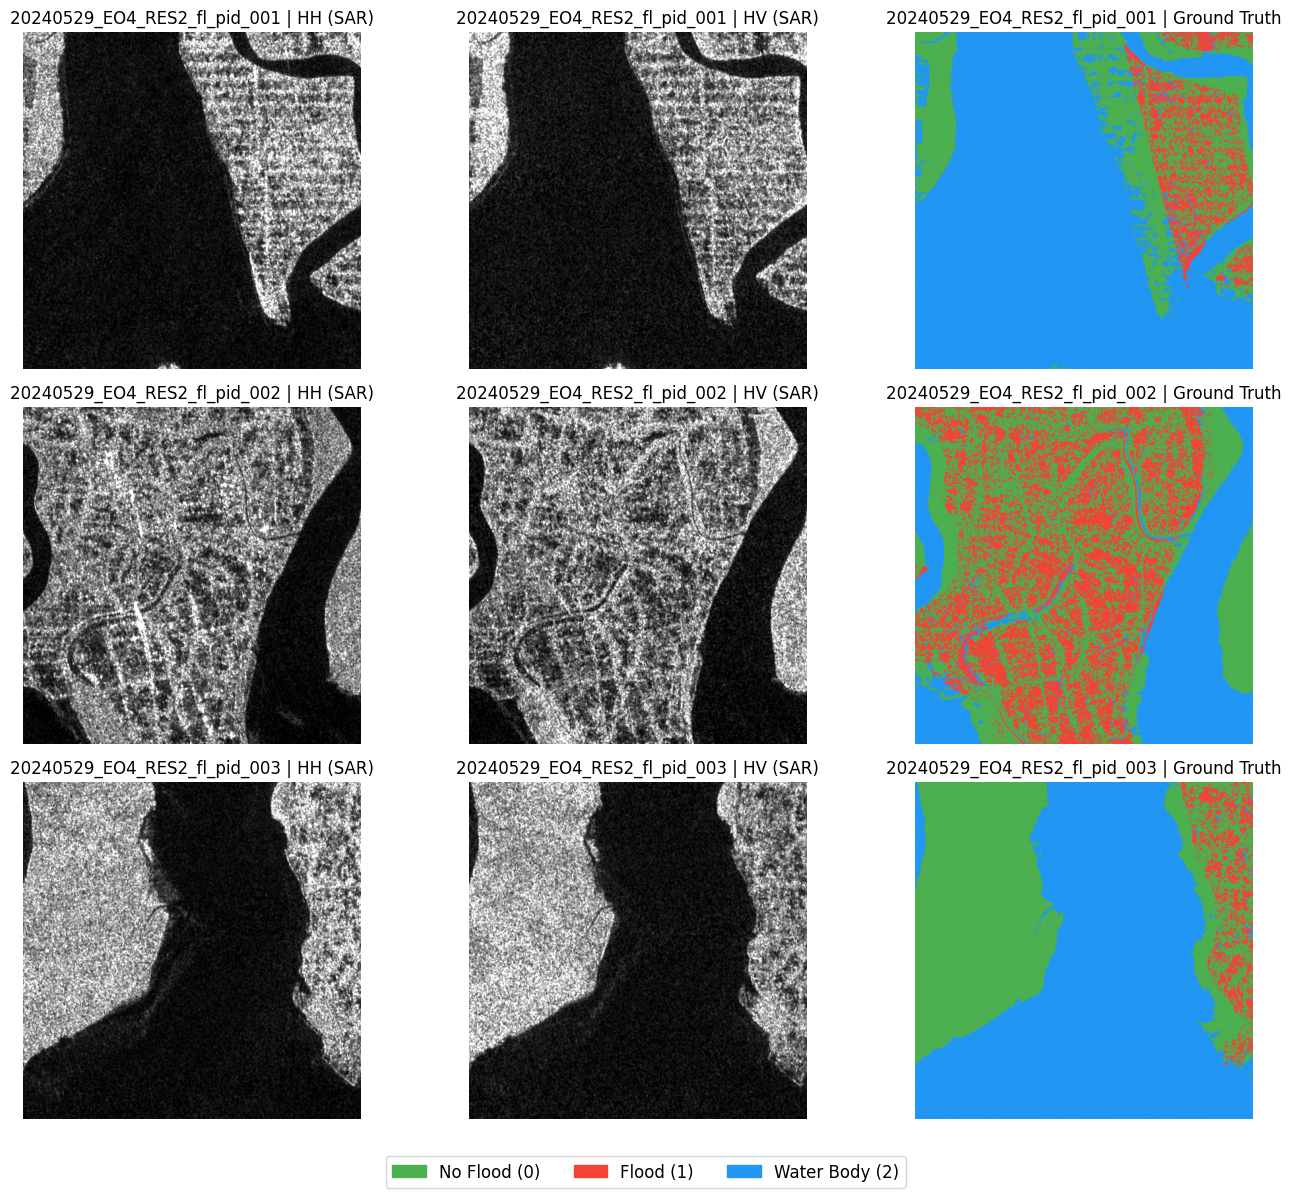

In [8]:
import os
import tifffile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Kaggle Dataset Paths
IMAGE_DIR = "/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/image"
LABEL_DIR = "/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/label"

# ---------------------------------------------------------
# Set the TWO bands you want to visualize
# Options: 0=HH, 1=HV, 2=Green, 3=Red, 4=NIR, 5=SWIR
BAND_A = 0  # e.g., HH
BAND_B = 1  # e.g., NIR
# ---------------------------------------------------------

band_names = {0: "HH (SAR)", 1: "HV (SAR)", 2: "Green (Opt)", 3: "Red (Opt)", 4: "NIR (Opt)", 5: "SWIR (Opt)"}

def percentile_norm(band, lo=2, hi=98):
    """Normalize raw satellite pixel values for human visualization"""
    valid = band[band != 0]
    if len(valid) == 0: return np.zeros_like(band)
    p_lo, p_hi = np.percentile(valid, [lo, hi])
    return np.clip((band - p_lo) / (p_hi - p_lo + 1e-6), 0, 1)

# Pick 3 images that have ground truth labels
label_files = [f for f in sorted(os.listdir(LABEL_DIR)) if f.endswith(".tif")][:3]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for i, lbl_file in enumerate(label_files):
    pid = lbl_file.replace("_label.tif", "")
    img_file = f"{pid}_image.tif"
    
    # Load TIF files
    img_path = os.path.join(IMAGE_DIR, img_file)
    lbl_path = os.path.join(LABEL_DIR, lbl_file)
    
    img = np.nan_to_num(tifffile.imread(img_path).astype(np.float32), nan=0.0)
    lbl = np.nan_to_num(tifffile.imread(lbl_path).astype(np.int32), nan=0)
    
    # Plot Selected Band 1
    axes[i, 0].imshow(percentile_norm(img[:, :, BAND_A]), cmap="gray")
    axes[i, 0].set_title(f"{pid} | {band_names[BAND_A]}")
    axes[i, 0].axis("off")
    
    # Plot Selected Band 2
    axes[i, 1].imshow(percentile_norm(img[:, :, BAND_B]), cmap="gray")
    axes[i, 1].set_title(f"{pid} | {band_names[BAND_B]}")
    axes[i, 1].axis("off")
    
    # Plot Ground Truth Label
    cmap = plt.cm.colors.ListedColormap(['#4CAF50', '#F44336', '#2196F3']) # Green, Red, Blue
    norm = plt.cm.colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)
    
    axes[i, 2].imshow(lbl, cmap=cmap, norm=norm)
    axes[i, 2].set_title(f"{pid} | Ground Truth")
    axes[i, 2].axis("off")

# Legend
patches = [
    mpatches.Patch(color='#4CAF50', label='No Flood (0)'),
    mpatches.Patch(color='#F44336', label='Flood (1)'),
    mpatches.Patch(color='#2196F3', label='Water Body (2)')
]
fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [9]:
train_loader, val_loader, test_loader, pred_loader, pred_ds = build_dataloaders()

# Quick sanity check
sample = next(iter(train_loader))
print(f"Image batch: {sample['image'].shape}")  # (B, 6, 512, 512)
print(f"Mask batch:  {sample['mask'].shape}")    # (B, 512, 512)
print(f"Mask classes: {sample['mask'].unique().tolist()}")

Train: 59 | Val: 10 | Test: 10 | Predict: 19
Image batch: torch.Size([4, 5, 512, 512])
Mask batch:  torch.Size([4, 512, 512])
Mask classes: [0, 1, 2]


## 4. Model — UNetPP + ResNet101 + Channel Adapter

In [10]:
class CBAMChannelAttention(nn.Module):
    """Channel attention from CBAM — learns which input bands are most informative."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        avg_out = self.mlp(self.avg_pool(x).view(b, c))
        max_out = self.mlp(self.max_pool(x).view(b, c))
        attention = torch.sigmoid(avg_out + max_out).view(b, c, 1, 1)
        return x * attention


class ChannelAdapter(nn.Module):
    """
    Projects 6-channel satellite input → 3 channels for ImageNet-pretrained backbone.

    Why: ResNet50 was trained on RGB (3ch). Our data has 6 bands (HH, HV, G, R, NIR, SWIR).
    Instead of destroying pretrained weights by modifying conv1, we learn a small projection
    that outputs well-formed 3-channel input the backbone can process.
    """
    def __init__(self, in_channels=6, out_channels=3, mid_channels=32):
        super().__init__()
        self.adapter = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, 1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.GELU(),
            nn.Conv2d(mid_channels, mid_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.GELU(),
        )
        self.attention = CBAMChannelAttention(mid_channels)
        self.project = nn.Sequential(
            nn.Conv2d(mid_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        x = self.adapter(x)
        x = self.attention(x)
        x = self.project(x)
        return x


class FloodSegModel(nn.Module):
    """
    UNet with ResNet50 encoder + Channel Adapter.

    - Adapter: 6ch → 3ch (keeps ImageNet weights intact)
    - Encoder: ResNet50 (ImageNet pretrained, downloaded programmatically)
    - Decoder: UNet
    - Head: 3-class segmentation
    """
    def __init__(self, num_classes=3, backbone="resnet50", in_channels=6):
        super().__init__()

        self.adapter = ChannelAdapter(in_channels=in_channels, out_channels=3)

        # SMP downloads ImageNet weights programmatically (Rule 6.2.3 compliant)
        self.seg_model = smp.UnetPlusPlus(
            encoder_name=backbone,
            encoder_weights="imagenet",  # Downloaded at runtime
            in_channels=3,               # Adapter output
            classes=num_classes,
            encoder_output_stride=8,
            decoder_channels=(256, 128, 64, 32, 16),
        )

    def forward(self, x):
        x = self.adapter(x)       # (B, 6, H, W) → (B, 3, H, W)
        x = self.seg_model(x)     # (B, 3, H, W) → (B, num_classes, H, W)
        return x

In [11]:
# Build model
in_channels = len(CONFIG["input_bands"]) + len(CONFIG["spectral_indices"])
model = FloodSegModel(
    num_classes=CONFIG["num_classes"],
    backbone=CONFIG["backbone"],
    in_channels=in_channels,
).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: UNetPP + {CONFIG['backbone']}")
print(f"Parameters: {total_params:,} total, {trainable_params:,} trainable")
print(f"Input channels: {in_channels}, Output classes: {CONFIG['num_classes']}")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/179M [00:00<?, ?B/s]

Model: UNetPP + resnet101
Parameters: 67,988,281 total, 67,988,281 trainable
Input channels: 5, Output classes: 3


## 5. Loss — Focal Loss with Class Weighting

In [12]:
class FocalLoss(nn.Module):
    """
    Focal Loss for multi-class segmentation.

    Addresses class imbalance by down-weighting easy examples:
    FL = -α * (1 - p_t)^γ * log(p_t)

    Class weights (α) focus training on flood detection:
    - No Flood (65.6%): α=0.15 (easy, dominant class)
    - Flood (13.5%):    α=0.50 (hard, target class — highest weight)
    - Water Body (20.9%): α=0.35 (moderate)
    """
    def __init__(self, gamma=2.0, alpha=None, ignore_index=-1):
        super().__init__()
        self.gamma = gamma
        self.ignore_index = ignore_index
        if alpha is not None:
            self.register_buffer("alpha", torch.tensor(alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction="none",
                                  ignore_index=self.ignore_index)
        pt = torch.exp(-ce_loss)
        focal_weight = (1 - pt) ** self.gamma
        loss = focal_weight * ce_loss

        if self.alpha is not None:
            alpha_t = self.alpha[targets.clamp(0, len(self.alpha) - 1)]
            loss = alpha_t * loss

        return loss.mean()


class DiceLoss(nn.Module):
    """Soft Dice Loss for multi-class segmentation."""
    def __init__(self, smooth=1e-6, ignore_index=-1):
        super().__init__()
        self.smooth = smooth
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        num_classes = logits.shape[1]
        probs = F.softmax(logits, dim=1)

        mask = (targets != self.ignore_index)
        targets_clean = targets.clone()
        targets_clean[~mask] = 0
        targets_oh = F.one_hot(targets_clean, num_classes).permute(0, 3, 1, 2).float()

        mask_expanded = mask.unsqueeze(1).float()
        probs = probs * mask_expanded
        targets_oh = targets_oh * mask_expanded

        dims = (0, 2, 3)
        intersection = (probs * targets_oh).sum(dim=dims)
        cardinality = probs.sum(dim=dims) + targets_oh.sum(dim=dims)
        dice = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
        return 1.0 - dice.mean()


class FocalDiceLoss(nn.Module):
    """Combined Focal + Dice — best of both worlds."""
    def __init__(self, focal_weight=1.0, dice_weight=1.0, gamma=2.0, alpha=None):
        super().__init__()
        self.focal_weight = focal_weight
        self.dice_weight = dice_weight
        self.focal = FocalLoss(gamma=gamma, alpha=alpha)
        self.dice = DiceLoss()

    def forward(self, logits, targets):
        return self.focal_weight * self.focal(logits, targets) + \
               self.dice_weight * self.dice(logits, targets)


class CEDiceLoss(nn.Module):
    """Combined CrossEntropy + Dice — simpler but effective."""
    def __init__(self, ce_weight=1.0, dice_weight=1.0, class_weights=None):
        super().__init__()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight
        self.dice = DiceLoss()
        if class_weights is not None:
            self.register_buffer("class_weights", torch.tensor(class_weights, dtype=torch.float32))
        else:
            self.class_weights = None

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.class_weights, ignore_index=-1)
        dice = self.dice(logits, targets)
        return self.ce_weight * ce + self.dice_weight * dice


def build_loss(loss_name):
    """Factory: build loss function by name."""
    alpha = CONFIG["focal_alpha"]
    gamma = CONFIG["focal_gamma"]

    if loss_name == "focal":
        return FocalLoss(gamma=gamma, alpha=alpha).to(DEVICE)
    elif loss_name == "dice":
        return DiceLoss().to(DEVICE)
    elif loss_name == "focal_dice":
        return FocalDiceLoss(gamma=gamma, alpha=alpha).to(DEVICE)
    elif loss_name == "ce_dice":
        return CEDiceLoss(class_weights=alpha).to(DEVICE)
    elif loss_name == "ce":
        return nn.CrossEntropyLoss(
            weight=torch.tensor(alpha, dtype=torch.float32).to(DEVICE),
            ignore_index=-1,
        )
    else:
        raise ValueError(f"Unknown loss: {loss_name}")

In [13]:
criterion = FocalDiceLoss(
    gamma=CONFIG["focal_gamma"],
    alpha=CONFIG["focal_alpha"],
).to(DEVICE)

print(f"Loss: Focal (γ={CONFIG['focal_gamma']}, α={CONFIG['focal_alpha']})")

Loss: Focal (γ=2.0, α=[0.15, 0.6, 0.25])


## 6. Metrics — Per-Class IoU

In [14]:
class MetricTracker:
    """Tracks per-class IoU, mean IoU, and pixel accuracy across batches."""

    CLASS_NAMES = {0: "no_flood", 1: "flood", 2: "water_body"}

    def __init__(self, num_classes=3):
        self.num_classes = num_classes
        self.reset()

    def reset(self):
        self.intersection = np.zeros(self.num_classes)
        self.union = np.zeros(self.num_classes)
        self.correct = 0
        self.total = 0

    @torch.no_grad()
    def update(self, preds, targets, ignore_index=-1):
        """preds, targets: (B, H, W) tensors."""
        mask = targets != ignore_index
        p = preds[mask]
        t = targets[mask]

        self.correct += (p == t).sum().item()
        self.total += mask.sum().item()

        for cls in range(self.num_classes):
            pc = (p == cls)
            tc = (t == cls)
            self.intersection[cls] += (pc & tc).sum().item()
            self.union[cls] += (pc | tc).sum().item()

    def compute(self):
        eps = 1e-6
        results = {}
        ious = []
        for cls in range(self.num_classes):
            iou = (self.intersection[cls] + eps) / (self.union[cls] + eps)
            name = self.CLASS_NAMES.get(cls, f"class_{cls}")
            results[f"iou_{name}"] = iou
            ious.append(iou)
        results["mean_iou"] = np.mean(ious)
        results["accuracy"] = self.correct / (self.total + eps)
        return results

## 7. Training Loop

In [15]:
def freeze_backbone(model):
    """Freeze the encoder (backbone) weights."""
    for param in model.seg_model.encoder.parameters():
        param.requires_grad = False
    print("[FREEZE] Backbone frozen")

def unfreeze_backbone(model):
    """Unfreeze the encoder (backbone) weights."""
    for param in model.seg_model.encoder.parameters():
        param.requires_grad = True
    print("[UNFREEZE] Backbone unfrozen")


def train_one_epoch(model, loader, criterion, optimizer, scaler, epoch, grad_accum):
    """Train for one epoch with mixed precision and gradient accumulation."""
    model.train()
    metrics = MetricTracker()
    running_loss = 0.0
    optimizer.zero_grad()

    for batch_idx, batch in enumerate(loader):
        images = batch["image"].to(DEVICE, non_blocking=True)
        masks = batch["mask"].to(DEVICE, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=CONFIG["mixed_precision"]):
            logits = model(images)
            loss = criterion(logits, masks) / grad_accum

        scaler.scale(loss).backward()

        if (batch_idx + 1) % grad_accum == 0 or (batch_idx + 1) == len(loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        running_loss += loss.item() * grad_accum
        preds = logits.argmax(dim=1)
        metrics.update(preds, masks)

    avg_loss = running_loss / len(loader)
    results = metrics.compute()
    results["loss"] = avg_loss
    return results


@torch.no_grad()
def validate(model, loader, criterion):
    """Validate the model."""
    model.eval()
    metrics = MetricTracker()
    running_loss = 0.0

    for batch in loader:
        images = batch["image"].to(DEVICE, non_blocking=True)
        masks = batch["mask"].to(DEVICE, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=CONFIG["mixed_precision"]):
            logits = model(images)
            loss = criterion(logits, masks)

        running_loss += loss.item()
        preds = logits.argmax(dim=1)
        metrics.update(preds, masks)

    avg_loss = running_loss / len(loader)
    results = metrics.compute()
    results["loss"] = avg_loss
    return results


def train(model, train_loader, val_loader, criterion):
    """Full training loop with freeze/unfreeze, early stopping, checkpointing."""
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=CONFIG["epochs"],
        eta_min=CONFIG["eta_min"],
    )

    scaler = torch.amp.GradScaler("cuda", enabled=CONFIG["mixed_precision"])

    freeze_epochs = CONFIG["freeze_backbone_epochs"]
    if freeze_epochs > 0:
        freeze_backbone(model)

    # Tracking — optimise for flood IoU
    best_flood_iou = 0.0
    best_epoch = 0
    patience_counter = 0
    best_state = None
    history = {
        "train_loss": [], "val_loss": [],
        "train_miou": [], "val_miou": [],
        "val_iou_flood": [], "val_iou_water": [], "lr": []
    }

    print(f"\n{'='*70}")
    print(f"  Starting Training: {CONFIG['epochs']} epochs, LR={CONFIG['learning_rate']}")
    print(f"  Effective batch size: {CONFIG['batch_size']} × {CONFIG['grad_accum_steps']} = {CONFIG['batch_size'] * CONFIG['grad_accum_steps']}")
    print(f"  Checkpoint selection: VAL FLOOD IoU")
    print(f"{'='*70}\n")

    for epoch in range(CONFIG["epochs"]):
        t0 = time.time()

        if freeze_epochs > 0 and epoch == freeze_epochs:
            unfreeze_backbone(model)

        train_results = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler,
            epoch, CONFIG["grad_accum_steps"]
        )

        val_results = validate(model, val_loader, criterion)

        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step()

        history["train_loss"].append(train_results["loss"])
        history["val_loss"].append(val_results["loss"])
        history["train_miou"].append(train_results["mean_iou"])
        history["val_miou"].append(val_results["mean_iou"])
        history["val_iou_flood"].append(val_results.get("iou_flood", 0))
        history["val_iou_water"].append(val_results.get("iou_water_body", 0))
        history["lr"].append(current_lr)

        elapsed = time.time() - t0

        print(
            f"Epoch {epoch+1:3d}/{CONFIG['epochs']} "
            f"| Train Loss: {train_results['loss']:.4f} mIoU: {train_results['mean_iou']:.4f} "
            f"| Val Loss: {val_results['loss']:.4f} mIoU: {val_results['mean_iou']:.4f} "
            f"| Flood: {val_results.get('iou_flood', 0):.4f} "
            f"| Water: {val_results.get('iou_water_body', 0):.4f} "
            f"| LR: {current_lr:.2e} "
            f"| {elapsed:.1f}s"
        )

        # Checkpointing by flood IoU
        val_flood_iou = val_results.get("iou_flood", 0)
        if val_flood_iou > best_flood_iou:
            best_flood_iou = val_flood_iou
            best_epoch = epoch + 1
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"  ★ New best: Flood IoU={best_flood_iou:.4f} at epoch {best_epoch}")
        else:
            patience_counter += 1

        if patience_counter >= CONFIG["patience"]:
            print(f"\n[EARLY STOP] No improvement in flood IoU for {CONFIG['patience']} epochs. Stopping.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"\n[DONE] Restored best model from epoch {best_epoch} (Flood IoU={best_flood_iou:.4f})")

    return history, best_flood_iou, best_epoch



In [16]:
# Run training
history, best_flood_iou, best_epoch = train(model, train_loader, val_loader, criterion)

[FREEZE] Backbone frozen

  Starting Training: 100 epochs, LR=0.0001
  Effective batch size: 4 × 4 = 16
  Checkpoint selection: VAL FLOOD IoU

Epoch   1/100 | Train Loss: 0.8076 mIoU: 0.2725 | Val Loss: 0.8840 mIoU: 0.0771 | Flood: 0.0111 | Water: 0.2106 | LR: 1.00e-04 | 13.2s
  ★ New best: Flood IoU=0.0111 at epoch 1
Epoch   2/100 | Train Loss: 0.7125 mIoU: 0.4022 | Val Loss: 0.8138 mIoU: 0.1972 | Flood: 0.0427 | Water: 0.2746 | LR: 1.00e-04 | 9.9s
  ★ New best: Flood IoU=0.0427 at epoch 2
Epoch   3/100 | Train Loss: 0.6803 mIoU: 0.4433 | Val Loss: 0.7313 mIoU: 0.3677 | Flood: 0.0841 | Water: 0.4086 | LR: 9.99e-05 | 10.0s
  ★ New best: Flood IoU=0.0841 at epoch 3
Epoch   4/100 | Train Loss: 0.6375 mIoU: 0.5021 | Val Loss: 0.7049 mIoU: 0.4055 | Flood: 0.1166 | Water: 0.4284 | LR: 9.98e-05 | 10.0s
  ★ New best: Flood IoU=0.1166 at epoch 4
Epoch   5/100 | Train Loss: 0.6270 mIoU: 0.5012 | Val Loss: 0.6762 mIoU: 0.4262 | Flood: 0.1382 | Water: 0.4032 | LR: 9.96e-05 | 10.2s
  ★ New best: F

## 8. Training Curves

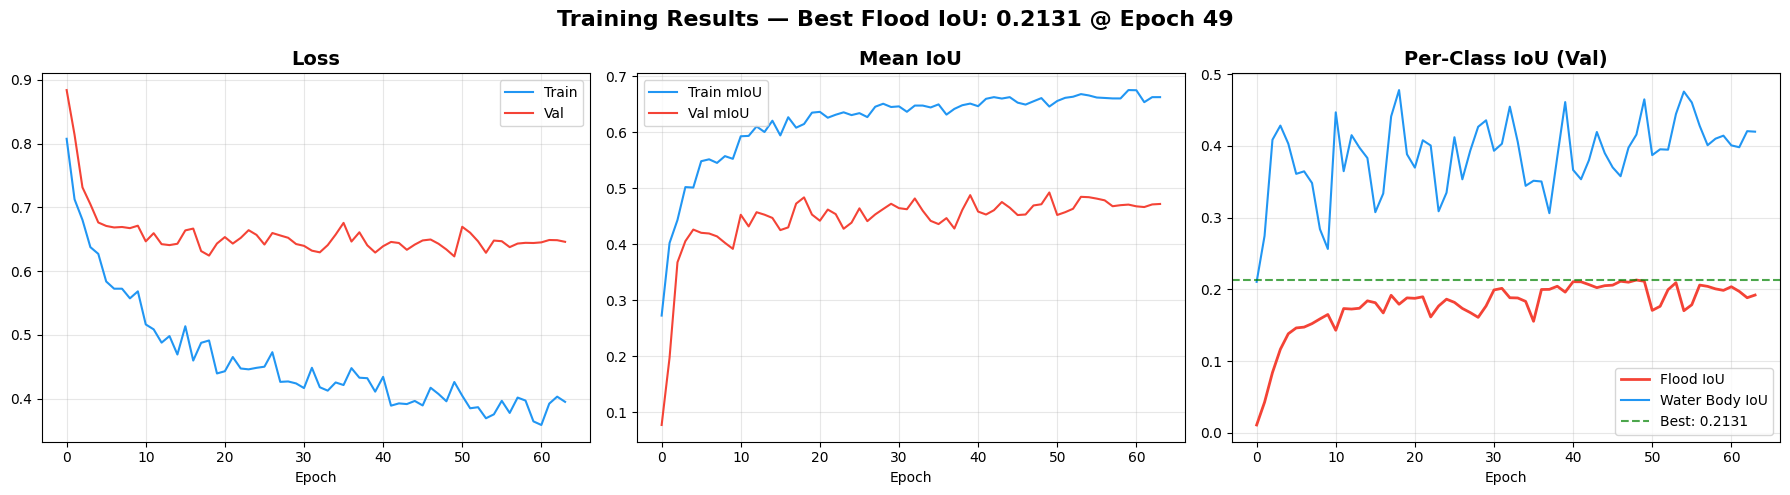

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history["train_loss"], label="Train", color="#2196F3")
axes[0].plot(history["val_loss"], label="Val", color="#F44336")
axes[0].set_title("Loss", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# mIoU
axes[1].plot(history["train_miou"], label="Train mIoU", color="#2196F3")
axes[1].plot(history["val_miou"], label="Val mIoU", color="#F44336")
axes[1].set_title("Mean IoU", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Per-class IoU — this is now the hero chart
axes[2].plot(history["val_iou_flood"], label="Flood IoU", color="#F44336", linewidth=2)
axes[2].plot(history["val_iou_water"], label="Water Body IoU", color="#2196F3")
axes[2].axhline(y=best_flood_iou, color="green", linestyle="--", alpha=0.7,
                label=f"Best: {best_flood_iou:.4f}")
axes[2].set_title("Per-Class IoU (Val)", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"Training Results — Best Flood IoU: {best_flood_iou:.4f} @ Epoch {best_epoch}",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Validation Visualization

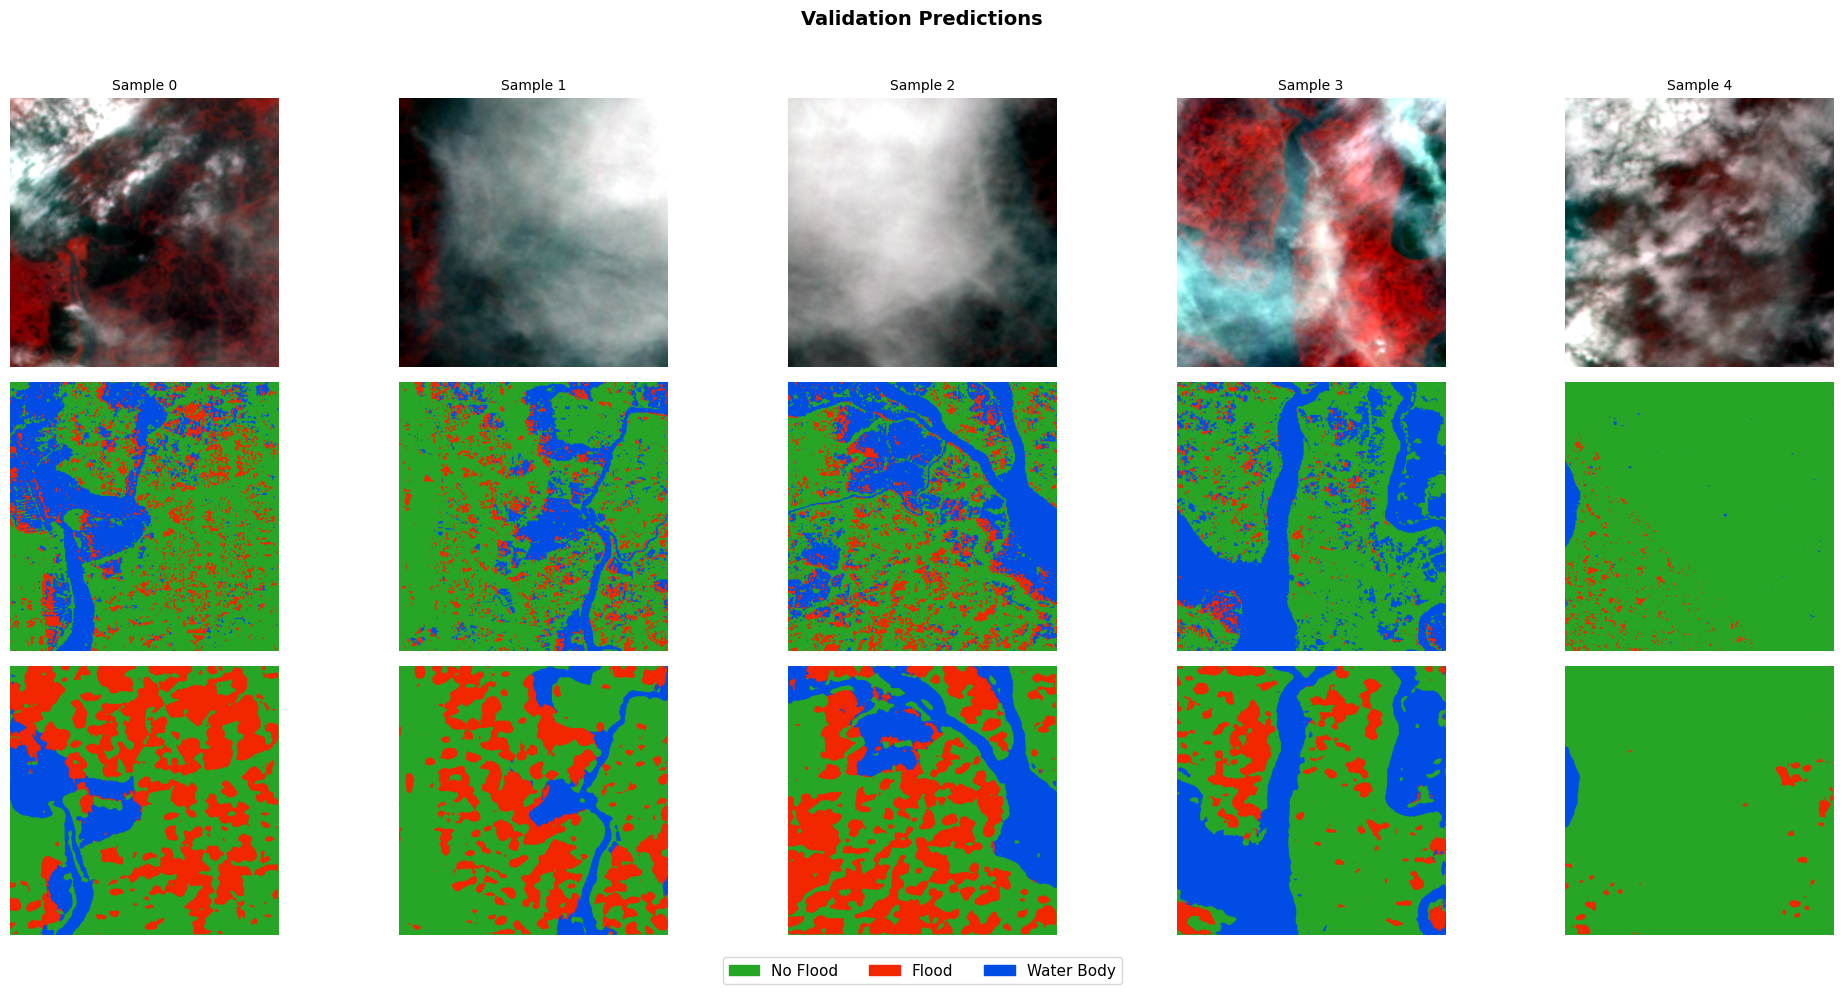

In [18]:
CLASS_COLORS = {
    0: [0.15, 0.65, 0.15],  # No Flood: green
    1: [0.95, 0.15, 0.0],   # Flood: red
    2: [0.0, 0.3, 0.9],     # Water Body: blue
}
CLASS_NAMES = {0: "No Flood", 1: "Flood", 2: "Water Body"}

def mask_to_rgb(mask):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3))
    for cls, color in CLASS_COLORS.items():
        rgb[mask == cls] = color
    return rgb

def percentile_norm(band, lo=2, hi=98):
    valid = band[band != 0]
    if len(valid) == 0:
        return np.zeros_like(band)
    p_lo, p_hi = np.percentile(valid, [lo, hi])
    return np.clip((band - p_lo) / (p_hi - p_lo + 1e-6), 0, 1)

# Predict on validation set
model.eval()
val_images, val_masks, val_preds = [], [], []

with torch.no_grad():
    for batch in val_loader:
        images = batch["image"].to(DEVICE)
        logits = model(images)
        preds = logits.argmax(dim=1).cpu().numpy()

        for i in range(images.shape[0]):
            val_images.append(batch["image"][i].numpy())
            val_masks.append(batch["mask"][i].numpy())
            val_preds.append(preds[i])

# Plot 5 samples
n_show = min(5, len(val_images))
fig, axes = plt.subplots(3, n_show, figsize=(4 * n_show, 10))
import matplotlib.patches as mpatches

for i in range(n_show):
    img = val_images[i]
    # False-color: NIR-Green-Red
    rgb = np.stack([percentile_norm(img[4]), percentile_norm(img[2]), percentile_norm(img[3])], axis=-1)

    axes[0, i].imshow(rgb)
    axes[0, i].set_title(f"Sample {i}", fontsize=10)
    axes[0, i].axis("off")

    axes[1, i].imshow(mask_to_rgb(val_masks[i]))
    axes[1, i].axis("off")

    axes[2, i].imshow(mask_to_rgb(val_preds[i]))
    axes[2, i].axis("off")

axes[0, 0].set_ylabel("NIR-G-R", fontsize=11)
axes[1, 0].set_ylabel("Ground Truth", fontsize=11)
axes[2, 0].set_ylabel("Prediction", fontsize=11)

patches = [mpatches.Patch(color=CLASS_COLORS[k], label=CLASS_NAMES[k]) for k in [0, 1, 2]]
fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=11)
plt.suptitle("Validation Predictions", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()

## 10. Test Set Evaluation (pid_070 → pid_079)
These 10 samples have ground truth labels but were NOT used during training.
This gives us the most honest estimate of real-world performance.

In [19]:
# Evaluate on test split
print("Evaluating on TEST split (10 held-out samples)...")
test_results = validate(model, test_loader, criterion)

print(f"\n{'='*60}")
print(f"  TEST SET RESULTS")
print(f"{'='*60}")
print(f"  Loss:           {test_results['loss']:.4f}")
print(f"  Mean IoU:       {test_results['mean_iou']:.4f}")
print(f"  Accuracy:       {test_results['accuracy']:.4f}")
print(f"  ─────────────────────────────────")
print(f"  IoU No Flood:   {test_results['iou_no_flood']:.4f}")
print(f"  IoU Flood:      {test_results['iou_flood']:.4f}  ← key metric")
print(f"  IoU Water Body: {test_results['iou_water_body']:.4f}")
print(f"{'='*60}")

Evaluating on TEST split (10 held-out samples)...

  TEST SET RESULTS
  Loss:           0.5410
  Mean IoU:       0.4926
  Accuracy:       0.7455
  ─────────────────────────────────
  IoU No Flood:   0.7786
  IoU Flood:      0.1779  ← key metric
  IoU Water Body: 0.5212


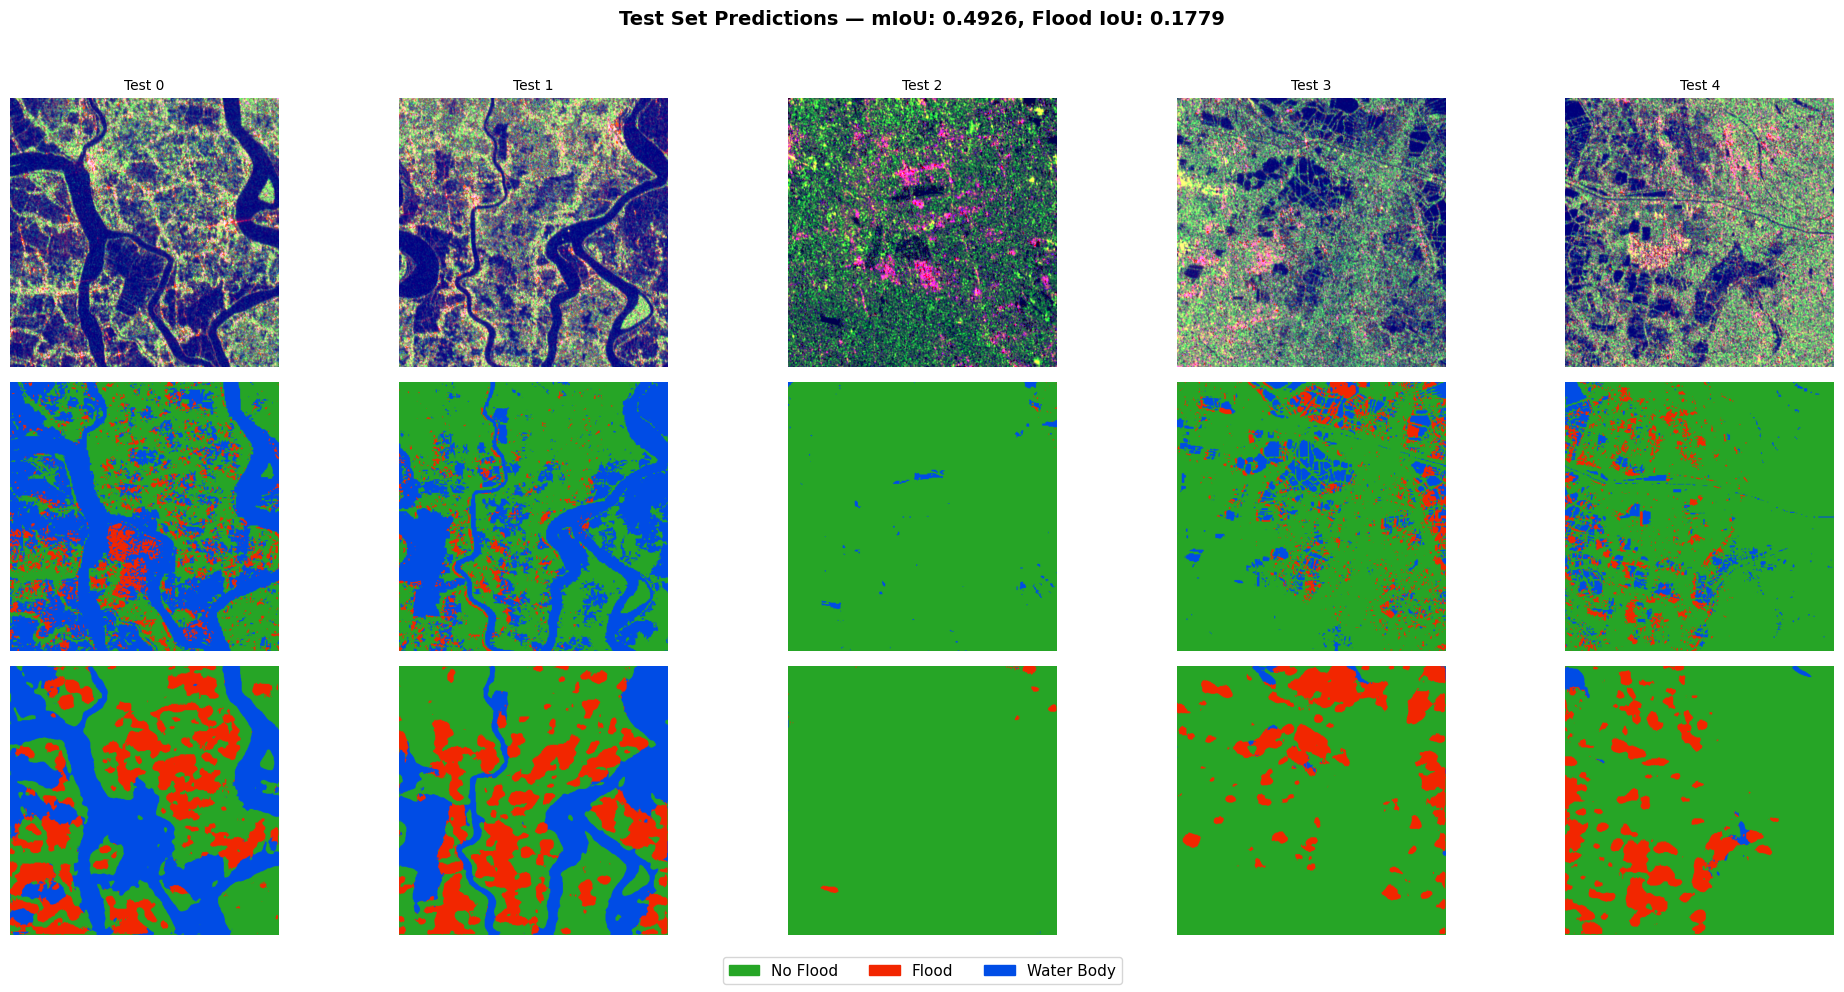

In [20]:
model.eval()
test_images, test_masks, test_preds = [], [], []

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(DEVICE)
        logits = model(images)
        preds = logits.argmax(dim=1).cpu().numpy()

        for i in range(images.shape[0]):
            test_images.append(batch["image"][i].numpy())
            test_masks.append(batch["mask"][i].numpy())
            test_preds.append(preds[i])


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

n_show = min(5, len(test_images))
fig, axes = plt.subplots(3, n_show, figsize=(4 * n_show, 10))

for i in range(n_show):
    img = test_images[i]

    # SAR visualization (VV, VH, Ratio)
    vv = percentile_norm(img[0])
    vh = percentile_norm(img[1])
    ratio = percentile_norm(img[0] / (img[1] + 1e-6))

    rgb = np.stack([vv, vh, ratio], axis=-1)

    # Input image
    axes[0, i].imshow(rgb)
    axes[0, i].set_title(f"Test {i}", fontsize=10)
    axes[0, i].axis("off")

    # Ground truth
    axes[1, i].imshow(mask_to_rgb(test_masks[i]))
    axes[1, i].axis("off")

    # Prediction
    axes[2, i].imshow(mask_to_rgb(test_preds[i]))
    axes[2, i].axis("off")


# Labels
axes[0, 0].set_ylabel("VV-VH-Ratio", fontsize=11)
axes[1, 0].set_ylabel("Ground Truth", fontsize=11)
axes[2, 0].set_ylabel("Prediction", fontsize=11)

# Legend
patches = [
    mpatches.Patch(color=CLASS_COLORS[k], label=CLASS_NAMES[k])
    for k in [0, 1, 2]
]

fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=11)

plt.suptitle(
    f"Test Set Predictions — mIoU: {test_results['mean_iou']:.4f}, "
    f"Flood IoU: {test_results['iou_flood']:.4f}",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()

## 11. Inference on Prediction Set

In [21]:
@torch.no_grad()
def predict_all(model, pred_loader):
    """Predict 3-class masks for all prediction images."""
    model.eval()
    predictions = []
    paths = []

    for batch in pred_loader:
        images = batch["image"].to(DEVICE)

        with torch.amp.autocast("cuda", enabled=CONFIG["mixed_precision"]):
            logits = model(images)

        preds = logits.argmax(dim=1).cpu().numpy()  # (B, H, W)

        for i in range(preds.shape[0]):
            predictions.append(preds[i])
            paths.append(batch["path"][i])

    print(f"[INFERENCE] Predicted {len(predictions)} images")
    return predictions, paths

predictions, pred_paths = predict_all(model, pred_loader)

# Quick check
print(f"\nPrediction stats:")
for i in range(min(3, len(predictions))):
    pred = predictions[i]
    pid = os.path.basename(pred_paths[i]).replace("_image.tif", "")
    n_flood = (pred == 1).sum()
    n_water = (pred == 2).sum()
    n_dry = (pred == 0).sum()
    print(f"  {pid}: flood={n_flood:,} water={n_water:,} dry={n_dry:,}")

[INFERENCE] Predicted 19 images

Prediction stats:
  20240529_EO4_RES2_fl_pid_080: flood=3,735 water=16,427 dry=241,982
  20240529_EO4_RES2_fl_pid_081: flood=19,104 water=21,758 dry=221,282
  20240529_EO4_RES2_fl_pid_082: flood=23,534 water=854 dry=237,756


In [22]:
# import rasterio
# from rasterio.warp import reproject, Resampling
# import numpy as np

# def load_and_align_jrc(jrc_path, reference_tif_path, threshold=50):
#     """
#     Load JRC occurrence/permanent tif and reproject+crop to match
#     a reference patch from your dataset.
#     Returns a binary mask (H, W) where 1 = permanent water.
#     """
#     with rasterio.open(reference_tif_path) as ref:
#         ref_crs = ref.crs
#         ref_transform = ref.transform
#         ref_shape = (ref.height, ref.width)

#     with rasterio.open(jrc_path) as jrc:
#         jrc_data = np.zeros(ref_shape, dtype=np.float32)
#         reproject(
#             source=rasterio.band(jrc, 1),
#             destination=jrc_data,
#             src_transform=jrc.transform,
#             src_crs=jrc.crs,
#             dst_transform=ref_transform,
#             dst_crs=ref_crs,
#             resampling=Resampling.nearest,
#         )

#     # threshold: occurrence > 50 means permanent water
#     permanent_mask = (jrc_data >= threshold).astype(bool)
#     return permanent_mask


# def apply_jrc_postprocess(pred_mask, jrc_permanent_mask):
#     """
#     pred_mask: (H, W) numpy array with values 0, 1, 2
#     jrc_permanent_mask: (H, W) bool array, True = permanent water

#     Logic:
#       - wherever model says water (1 or 2) AND jrc says permanent → set to 2
#       - wherever model says water (1 or 2) AND jrc says NOT permanent → set to 1
#       - non-water pixels (0) are untouched
#     """
#     final = pred_mask.copy()
#     predicted_water = (pred_mask == 1) | (pred_mask == 2)
#     final[predicted_water & jrc_permanent_mask] = 2   # permanent water
#     final[predicted_water & ~jrc_permanent_mask] = 1  # flood
#     return final

# JRC_PATH = "/kaggle/input/datasets/momoketchum/jrc-sundarbans/jrc_occurrence.tif"

# corrected_predictions = []
# for raw_pred, img_path in zip(predictions, pred_paths):
#     jrc_mask = load_and_align_jrc(JRC_PATH, img_path, threshold=50)
#     corrected = apply_jrc_postprocess(raw_pred, jrc_mask)
#     corrected_predictions.append(corrected)

# print("JRC post-processing done.")
# print(f"Processed {len(corrected_predictions)} prediction masks.")

## 12. Generate Submission CSV

In [23]:
def rle_encode(mask):
    """
    Run-Length Encode a binary mask.
    Column-major order (Fortran), 1-indexed (Kaggle convention).
    """
    pixels = mask.flatten(order='F')
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0]
    runs = runs.reshape(-1, 2)
    rle_pairs = []
    for start, end in runs:
        rle_pairs.append(f"{start + 1} {end - start}")
    return " ".join(rle_pairs)


def create_submission(predictions, paths, output_path="submission.csv"):
    """
    Create competition submission CSV.

    Format:
    - RLE encodes FLOOD pixels only (class 1)
    - Empty predictions → '0 0' (not blank)
    """
    rows = []
    for pred, path in zip(predictions, paths):
        image_id = os.path.basename(path).replace("_image.tif", "")

        # Binary flood mask
        flood_mask = (pred == 1).astype(np.uint8)

        if flood_mask.sum() == 0:
            rle = "0 0"  # Competition requires "0 0" for empty masks
        else:
            rle = rle_encode(flood_mask)

        rows.append({"id": image_id, "rle_mask": rle})

    df = pd.DataFrame(rows)
    df.to_csv(output_path, index=False)

    # Summary
    n_flood = sum(1 for r in rows if r["rle_mask"] != "0 0")
    print(f"\n[SUBMISSION] Saved to {output_path}")
    print(f"[SUBMISSION] {len(df)} images, {n_flood} with flood predictions")
    print(f"\nPreview:")
    print(df.head(10).to_string(index=False))
    return df

In [24]:
submission_df = create_submission(predictions, pred_paths, "submission.csv")
print("submission.csv generated")


[SUBMISSION] Saved to submission.csv
[SUBMISSION] 19 images, 19 with flood predictions

Preview:
                          id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

## 13. Final Summary

In [25]:
print("=" * 60)
print("  TRAINING COMPLETE — SUMMARY")
print("=" * 60)
print(f"  Model:        UNet + {CONFIG['backbone']}")
print(f"  Input:        {in_channels} bands → Channel Adapter → 3ch")
print(f"  Loss:         Focal (γ={CONFIG['focal_gamma']}, α={CONFIG['focal_alpha']})")
print(f"  TEST mIoU:    {test_results['mean_iou']:.4f}")
print(f"  TEST Flood:   {test_results['iou_flood']:.4f}")
print(f"  TEST Water:   {test_results['iou_water_body']:.4f}")
print(f"  TEST Acc:     {test_results['accuracy']:.4f}")
print(f"  ────────────────────────────────────────")
print(f"  Train:        {len(train_loader.dataset)} images")
print(f"  Val:          {len(val_loader.dataset)} images")
print(f"  Test:         {len(test_loader.dataset)} images")
print(f"  Predict:      {len(pred_ds)} images")
print(f"  Seed:         {SEED}")
print(f"  Submission:   submission.csv")
print("=" * 60)

  TRAINING COMPLETE — SUMMARY
  Model:        UNet + resnet101
  Input:        5 bands → Channel Adapter → 3ch
  Loss:         Focal (γ=2.0, α=[0.15, 0.6, 0.25])
  TEST mIoU:    0.4926
  TEST Flood:   0.1779
  TEST Water:   0.5212
  TEST Acc:     0.7455
  ────────────────────────────────────────
  Train:        59 images
  Val:          10 images
  Test:         10 images
  Predict:      19 images
  Seed:         42
  Submission:   submission.csv
